## Employee Attrition 



Objective:
To build a predictive model that identifies employees at risk of leaving the company, enabling HR teams to take proactive retention measures.


### Imports

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV






### Read the data

In [51]:
df = pd.read_csv('employee_attrition_dataset.csv')

### Prepare the dataset

In [52]:
df

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,4,2,1,3,4,14,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,9,1,2,1,1,6,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,14,8,3,2,1,77,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,8,2,3,5,4,49,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,10,1,2,5,1,64,No,3,33,0,4,1,3,44,3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,27,Female,Divorced,HR,Analyst,2,4172,76,24,14,3,4,5,4,76,No,4,46,10,3,1,4,24,4,No
996,997,47,Male,Single,IT,Manager,4,11007,71,19,6,0,3,1,1,53,Yes,7,36,16,3,2,4,39,3,Yes
997,998,50,Female,Divorced,IT,Executive,1,4641,43,25,12,3,4,1,1,7,Yes,1,46,9,2,3,3,33,2,No
998,999,28,Female,Married,HR,Executive,4,19855,92,13,13,0,2,2,2,54,No,4,52,17,4,1,4,41,4,No


In [53]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')

In [54]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [55]:
df.columns

Index(['employee_id', 'age', 'gender', 'marital_status', 'department',
       'job_role', 'job_level', 'monthly_income', 'hourly_rate',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'work_life_balance', 'job_satisfaction',
       'performance_rating', 'training_hours_last_year', 'overtime',
       'project_count', 'average_hours_worked_per_week', 'absenteeism',
       'work_environment_satisfaction', 'relationship_with_manager',
       'job_involvement', 'distance_from_home', 'number_of_companies_worked',
       'attrition'],
      dtype='object')

In [56]:
df.info()  
# there is no null values 
# There are 5 columns were stores as strings so we need to perform Encoding

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   employee_id                    1000 non-null   int64 
 1   age                            1000 non-null   int64 
 2   gender                         1000 non-null   object
 3   marital_status                 1000 non-null   object
 4   department                     1000 non-null   object
 5   job_role                       1000 non-null   object
 6   job_level                      1000 non-null   int64 
 7   monthly_income                 1000 non-null   int64 
 8   hourly_rate                    1000 non-null   int64 
 9   years_at_company               1000 non-null   int64 
 10  years_in_current_role          1000 non-null   int64 
 11  years_since_last_promotion     1000 non-null   int64 
 12  work_life_balance              1000 non-null   int64 
 13  job_

In [57]:
# Retrive the object type columns using condition



for col in df.columns:
    if df[col].dtype == 'object':
        print(f'\n{df[col].value_counts()}')


gender
Male      516
Female    484
Name: count, dtype: int64

marital_status
Married     348
Single      339
Divorced    313
Name: count, dtype: int64

department
Finance      218
HR           211
Sales        199
Marketing    198
IT           174
Name: count, dtype: int64

job_role
Manager      268
Executive    252
Analyst      251
Assistant    229
Name: count, dtype: int64

overtime
No     512
Yes    488
Name: count, dtype: int64

attrition
No     811
Yes    189
Name: count, dtype: int64


In [58]:
# Categories are nominal (no inherent order) , here i have performed LABEL ENCODING

label_cols =['gender','marital_status','department','job_role','overtime','attrition']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [59]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   employee_id                    1000 non-null   int64
 1   age                            1000 non-null   int64
 2   gender                         1000 non-null   int64
 3   marital_status                 1000 non-null   int64
 4   department                     1000 non-null   int64
 5   job_role                       1000 non-null   int64
 6   job_level                      1000 non-null   int64
 7   monthly_income                 1000 non-null   int64
 8   hourly_rate                    1000 non-null   int64
 9   years_at_company               1000 non-null   int64
 10  years_in_current_role          1000 non-null   int64
 11  years_since_last_promotion     1000 non-null   int64
 12  work_life_balance              1000 non-null   int64
 13  job_satisfaction   

In [60]:
df.head(6)

,employee_id,age,gender,marital_status,department,job_role,job_level,monthly_income,hourly_rate,years_at_company,years_in_current_role,years_since_last_promotion,work_life_balance,job_satisfaction,performance_rating,training_hours_last_year,overtime,project_count,average_hours_worked_per_week,absenteeism,work_environment_satisfaction,relationship_with_manager,job_involvement,distance_from_home,number_of_companies_worked,attrition
0,1,58,0,1,2,3,1,15488,28,15,4,2,1,3,4,14,0,6,54,17,4,4,4,20,3,0
1,2,48,0,1,4,1,5,13079,28,6,9,1,2,1,1,6,1,2,45,1,4,1,2,25,2,0
2,3,34,1,1,3,1,1,13744,24,24,14,8,3,2,1,77,1,6,34,2,3,4,4,45,3,0
3,4,27,0,0,3,3,1,6809,26,10,8,2,3,5,4,49,0,9,48,18,2,3,1,35,3,0
4,5,40,1,0,3,2,1,10206,52,29,10,1,2,5,1,64,0,3,33,0,4,1,3,44,3,0
5,6,58,1,0,0,1,3,16746,48,15,9,3,4,2,3,66,0,9,35,9,2,2,3,24,1,0


In [61]:
features = df.drop(columns=['employee_id'])
df = features.copy()


In [62]:
df

,age,gender,marital_status,department,job_role,job_level,monthly_income,hourly_rate,years_at_company,years_in_current_role,years_since_last_promotion,work_life_balance,job_satisfaction,performance_rating,training_hours_last_year,overtime,project_count,average_hours_worked_per_week,absenteeism,work_environment_satisfaction,relationship_with_manager,job_involvement,distance_from_home,number_of_companies_worked,attrition
0,58,0,1,2,3,1,15488,28,15,4,2,1,3,4,14,0,6,54,17,4,4,4,20,3,0
1,48,0,1,4,1,5,13079,28,6,9,1,2,1,1,6,1,2,45,1,4,1,2,25,2,0
2,34,1,1,3,1,1,13744,24,24,14,8,3,2,1,77,1,6,34,2,3,4,4,45,3,0
3,27,0,0,3,3,1,6809,26,10,8,2,3,5,4,49,0,9,48,18,2,3,1,35,3,0
4,40,1,0,3,2,1,10206,52,29,10,1,2,5,1,64,0,3,33,0,4,1,3,44,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,0,0,1,0,2,4172,76,24,14,3,4,5,4,76,0,4,46,10,3,1,4,24,4,0
996,47,1,2,2,3,4,11007,71,19,6,0,3,1,1,53,1,7,36,16,3,2,4,39,3,1
997,50,0,0,2,2,1,4641,43,25,12,3,4,1,1,7,1,1,46,9,2,3,3,33,2,0
998,28,0,1,1,2,4,19855,92,13,13,0,2,2,2,54,0,4,52,17,4,1,4,41,4,0


In [63]:
df.mean()

age                                 39.991
gender                               0.516
marital_status                       1.026
department                           1.949
job_role                             1.537
job_level                            3.055
monthly_income                   11499.899
hourly_rate                         57.837
years_at_company                    14.922
years_in_current_role                7.539
years_since_last_promotion           4.408
work_life_balance                    2.495
job_satisfaction                     3.151
performance_rating                   2.527
training_hours_last_year            50.043
overtime                             0.488
project_count                        4.877
average_hours_worked_per_week       44.553
absenteeism                          9.524
work_environment_satisfaction        2.494
relationship_with_manager            2.519
job_involvement                      2.503
distance_from_home                  24.507
number_of_c

In [64]:
pd.set_option('display.max_columns', None)

In [65]:
df.describe()

,age,gender,marital_status,department,job_role,job_level,monthly_income,hourly_rate,years_at_company,years_in_current_role,years_since_last_promotion,work_life_balance,job_satisfaction,performance_rating,training_hours_last_year,overtime,project_count,average_hours_worked_per_week,absenteeism,work_environment_satisfaction,relationship_with_manager,job_involvement,distance_from_home,number_of_companies_worked,attrition
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,39.991000,0.516000,1.02600,1.949000,1.537000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,0.488000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000,0.189000
std,11.780055,0.499994,0.80745,1.440998,1.134865,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,0.500106,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296,0.391705
min,20.000000,0.000000,0.00000,0.000000,0.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,30.000000,0.000000,0.00000,1.000000,0.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,0.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000,0.000000
50%,41.000000,1.000000,1.00000,2.000000,2.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,0.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000,0.000000
75%,50.250000,1.000000,2.00000,3.000000,3.000000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,1.000000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000,0.000000
max,59.000000,1.000000,2.00000,4.000000,3.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,1.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000,1.000000


In [66]:
continuous_cols = [col for col in df.columns 
                   if df[col].dtype in ['int64', 'float64'] and df[col].nunique() > 10]

In [67]:
continuous_cols

['age',
 'monthly_income',
 'hourly_rate',
 'years_at_company',
 'years_in_current_role',
 'training_hours_last_year',
 'average_hours_worked_per_week',
 'absenteeism',
 'distance_from_home']

### Exploratory Data Analysis(EDA)

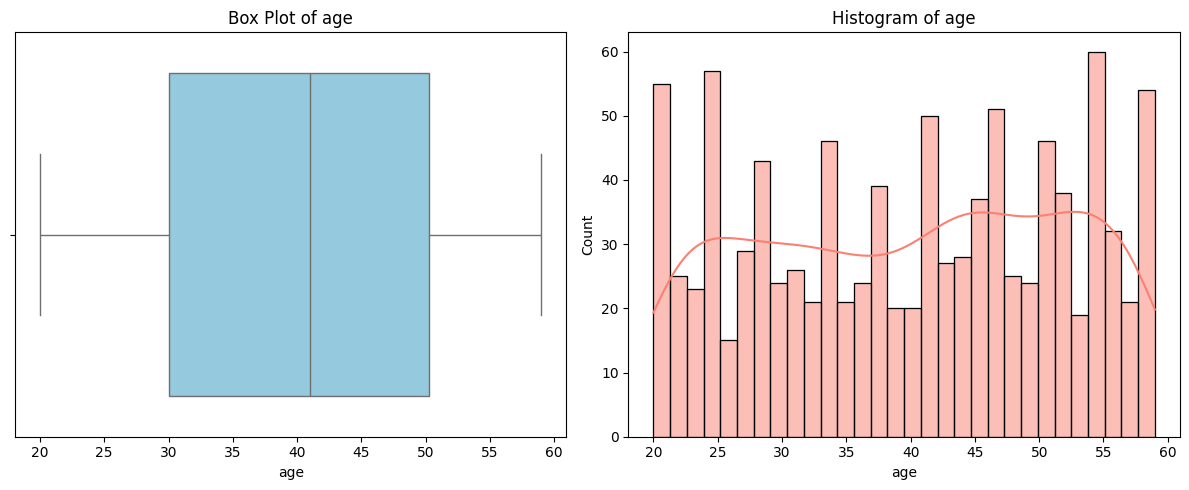

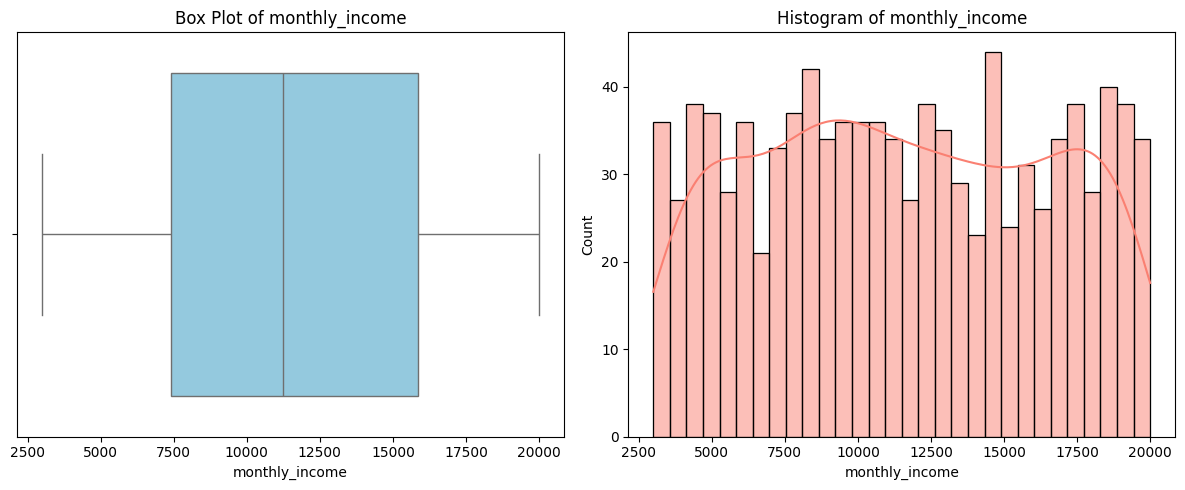

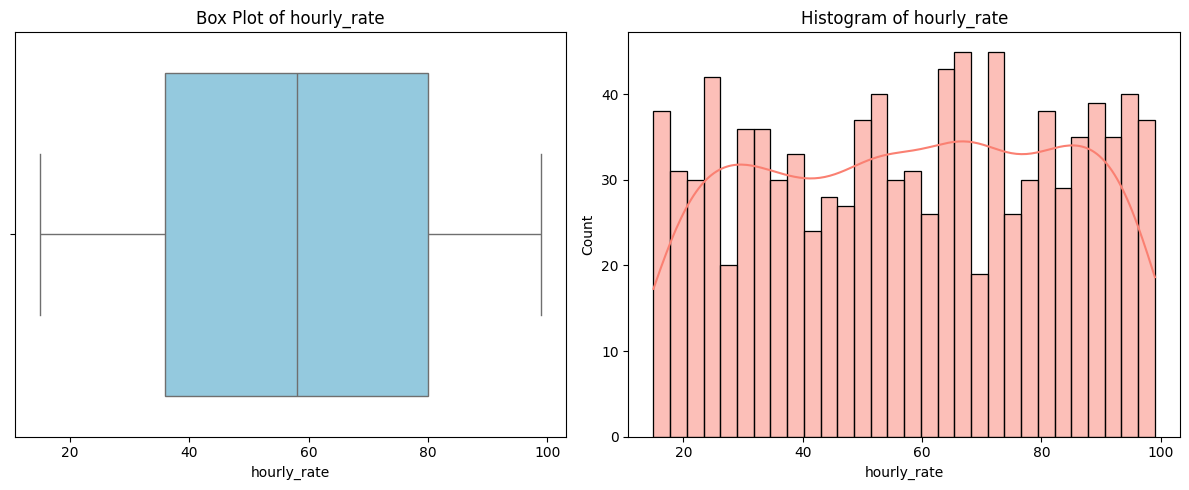

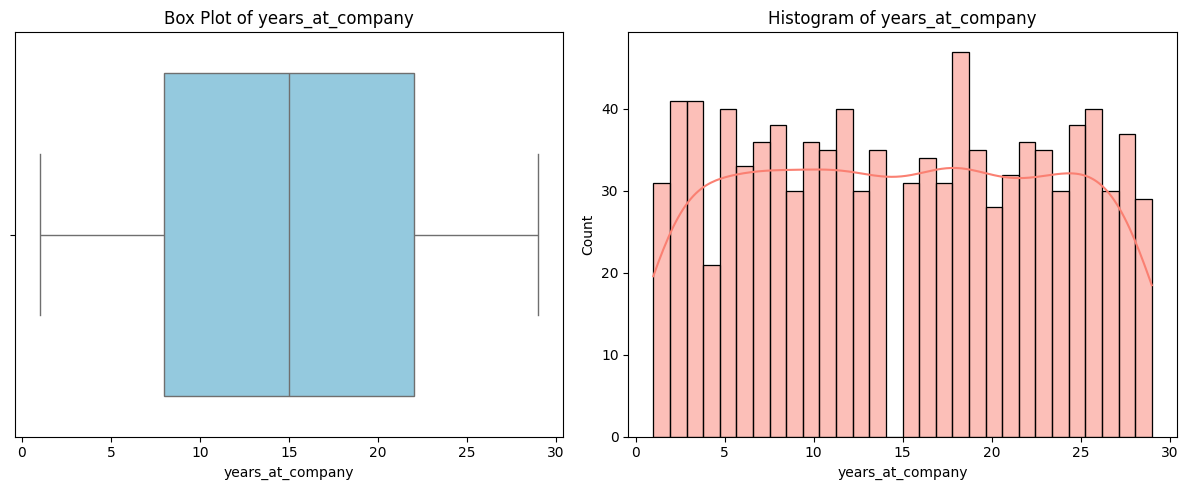

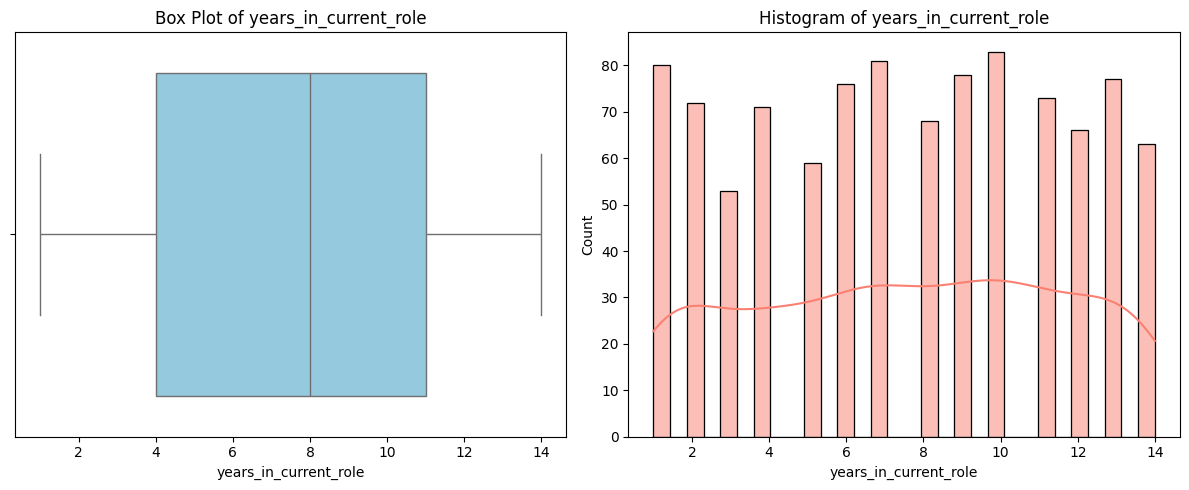

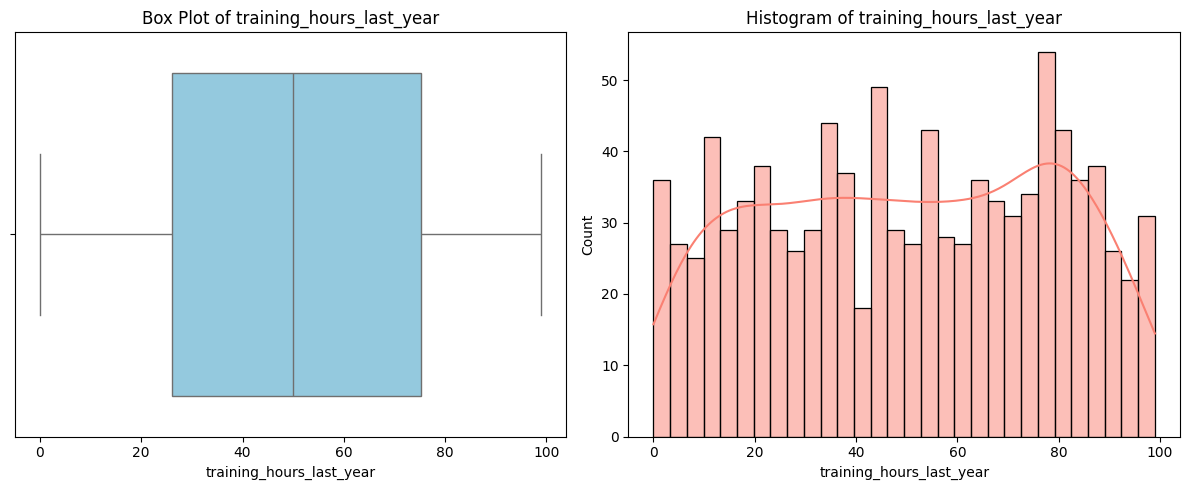

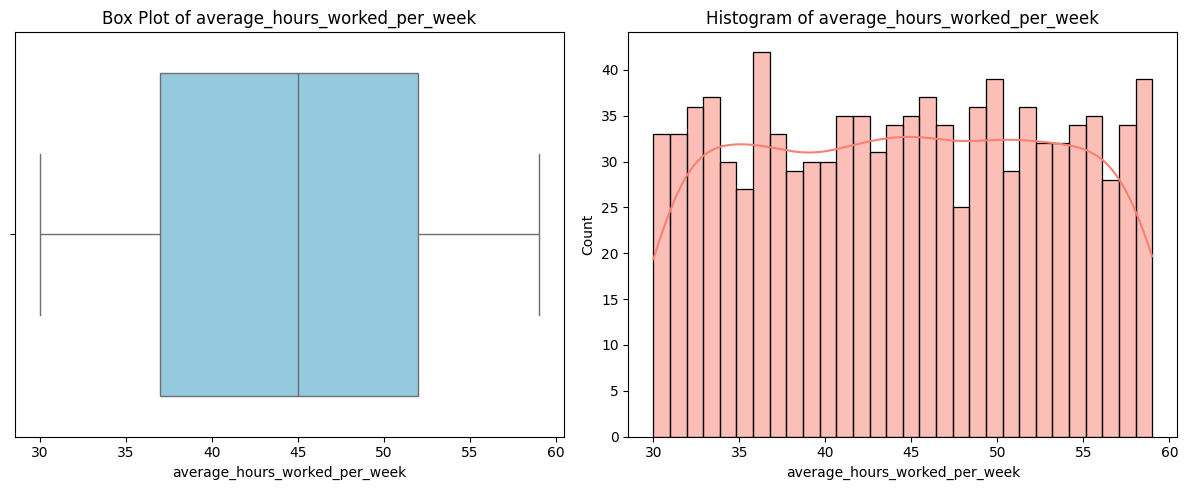

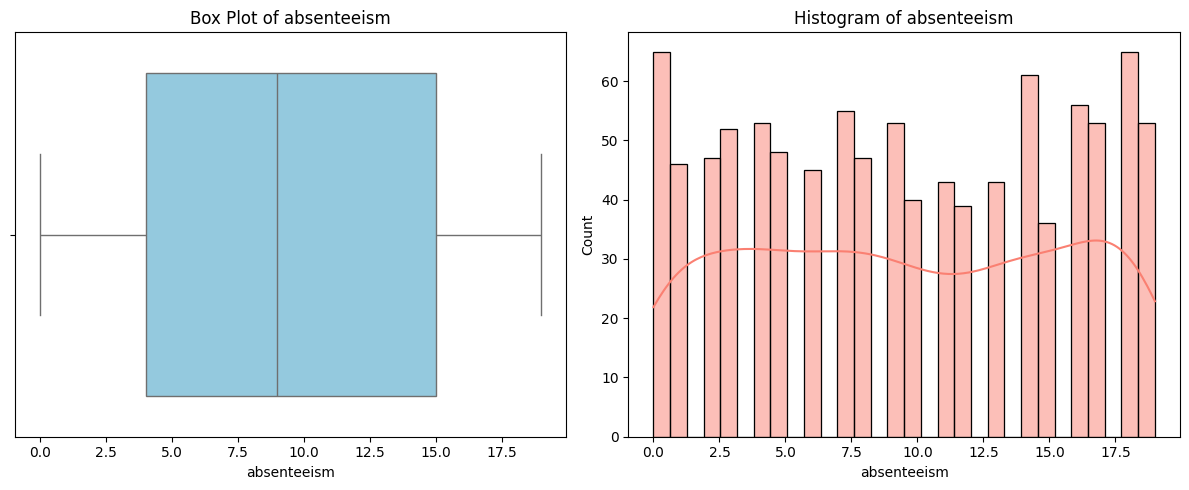

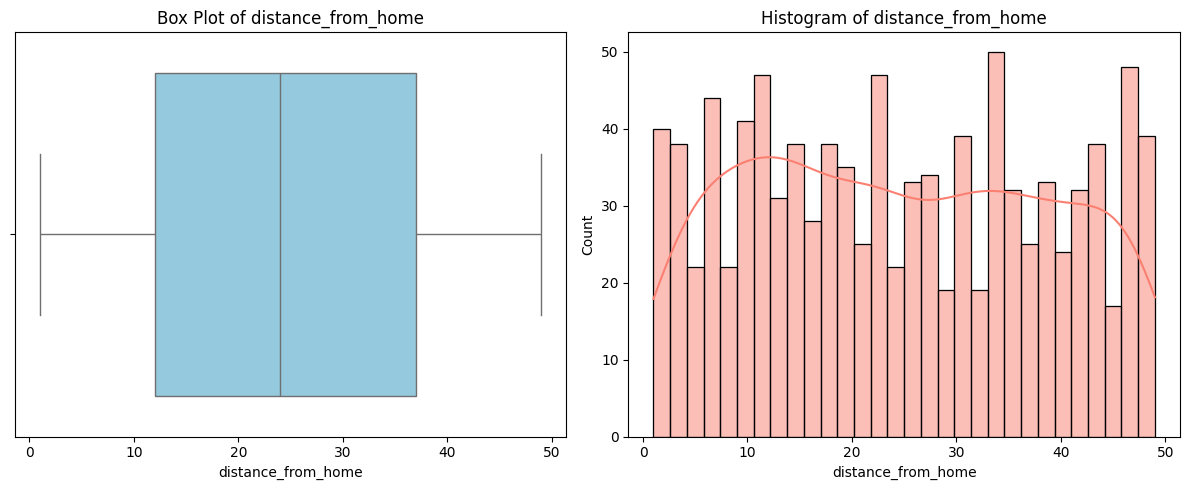

In [68]:
columns = ['age', 'monthly_income', 'hourly_rate', 'years_at_company',
    'years_in_current_role', 'training_hours_last_year',
    'average_hours_worked_per_week', 'absenteeism', 'distance_from_home'
]


for col in columns:
    plt.figure(figsize=(12, 5))

    # Box Plot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')

    # Histogram
    plt.subplot(1, 2, 2)
    sns.histplot(df[col], kde=True, color='salmon', bins=30)
    plt.title(f'Histogram of {col}')

    plt.tight_layout()
    plt.show()

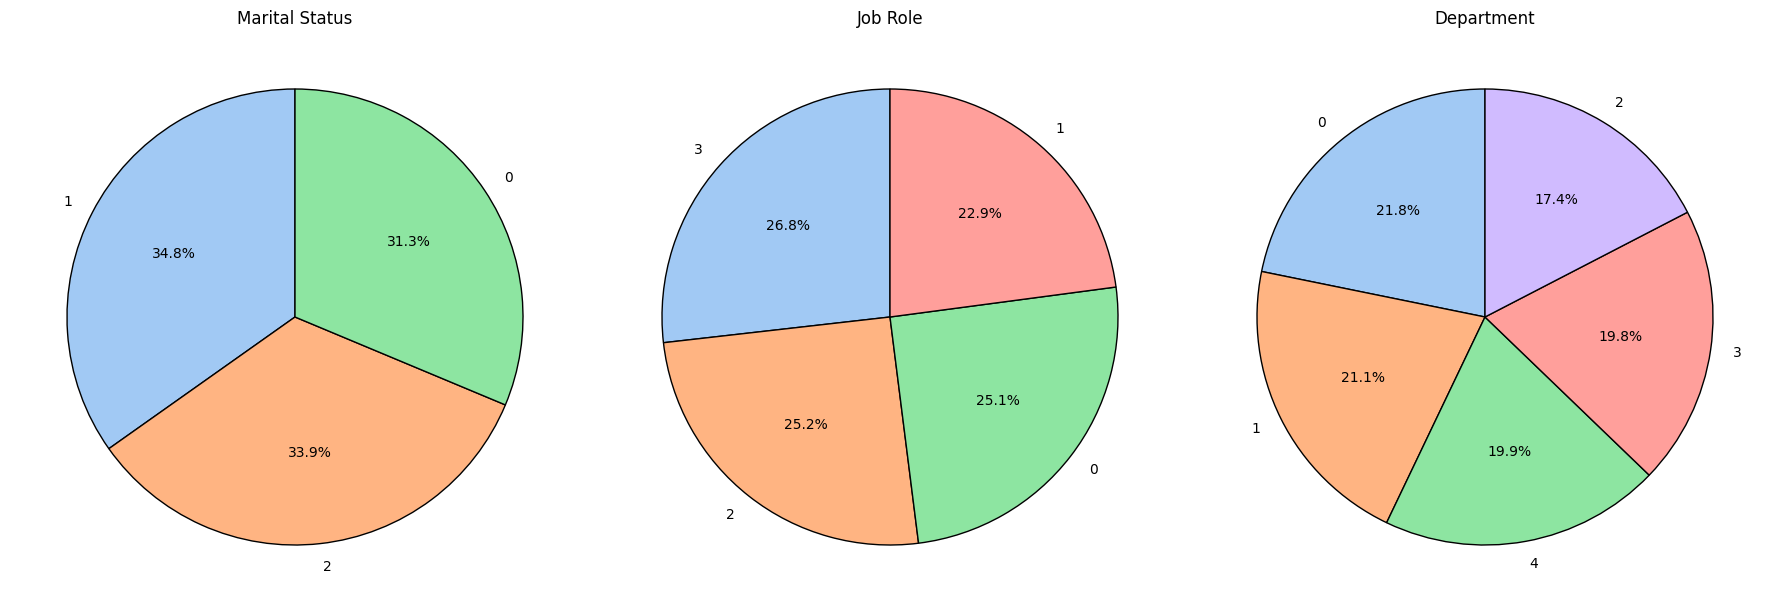

In [69]:
# List of categorical columns
cat_cols = ['marital_status', 'job_role', 'department']

# Set up subplot grid
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Loop through each column and plot pie chart
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                startangle=90, colors=sns.color_palette('pastel'),
                wedgeprops={'edgecolor': 'black'})
    axes[i].set_title(f'{col.replace("_", " ").title()}')

plt.tight_layout()
plt.show()


**Marital Status Distribution**
- The workforce is evenly split across all three categories.
- This balance suggests that marital status may not be a dominant factor in attrition or job satisfaction unless further segmented.

 **Job Role Distribution**
- Fairly balanced across four roles:
- No single role dominates, which is great for modeling — it avoids role bias and allows fair comparison across roles.


**Department Distribution**
- Again, a healthy distribution. No department is overrepresented, which helps ensure balanced modeling and fair HR insights.



C:\Users\JEEVA\AppData\Local\Temp\ipykernel_21228\3926779863.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_satisfaction.index, y=mean_satisfaction.values, palette='coolwarm')


TypeError: 'str' object is not callable

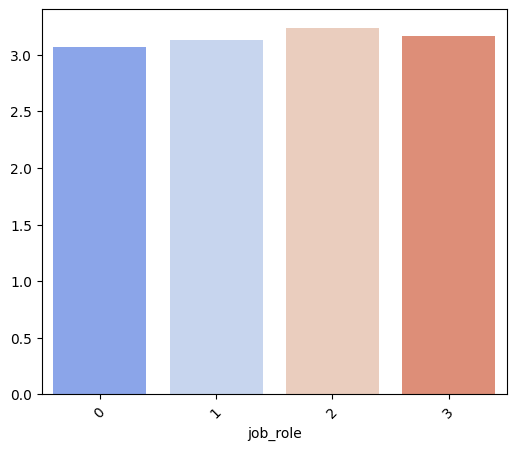

In [70]:
mean_satisfaction = df.groupby('job_role')['job_satisfaction'].mean().sort_values()

plt.figure(figsize=(6, 5))
sns.barplot(x=mean_satisfaction.index, y=mean_satisfaction.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.ylabel('Average Job Satisfaction')
plt.title('Average Job Satisfaction by Job Role')
plt.tight_layout()
plt.show()


- All four job roles (labeled 0 to 3) show similar average satisfaction scores, slightly above 3.0 on a scale of 0 to 4.
- This suggests that job satisfaction is relatively consistent across roles, with no major outliers or dissatisfaction spikes.


C:\Users\JEEVA\AppData\Local\Temp\ipykernel_21228\3213704658.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_attrition.values, y=corr_with_attrition.index, palette='coolwarm')


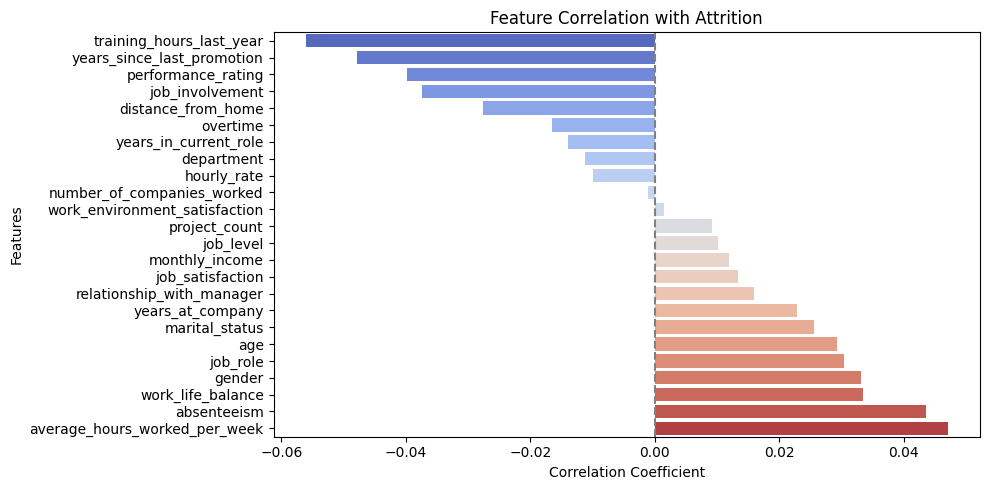

In [ ]:

# Compute correlation matrix
corr_matrix = df.corr()

# Extract correlations with attrition and drop self-correlation
corr_with_attrition = corr_matrix['attrition'].drop('attrition').sort_values()

# Plot as horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=corr_with_attrition.values, y=corr_with_attrition.index, palette='coolwarm')
plt.title('Feature Correlation with Attrition')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(0, color='gray', linestyle='--')  # Reference line at zero
plt.tight_layout()
plt.show()


**Top Negative Correlations (lower Attrition)**

- More training is linked to lower attrition — suggests that investing in employee development improves retention.
- Longer time since promotion slightly reduces attrition — possibly due to stability or lack of ambition to switch.
- Higher performers tend to stay — retention of top talent is working.
- Engaged employees are less likely to leave — a strong predictor for satisfaction.

 **Top Positive Correlations (Increase Attrition)**
 
 - Longer work hours slightly increase attrition — possible burnout signal.
 - More absences correlate with higher attrition — early warning for disengagement.
 - Gender-coded values show slight attrition difference — needs decoding and ethical interpretation.

### Skewness and Kurtosis

In [ ]:
# Continuous variables
num_cols = ['age', 'monthly_income', 'hourly_rate', 'years_at_company',
    'years_in_current_role', 'training_hours_last_year',
    'average_hours_worked_per_week', 'absenteeism', 'distance_from_home']

# Calculate skewness and kurtosis
for col in num_cols:
    skew_val = df[col].skew()
    kurtosis_val = df[col].kurt()
    print(f"{col} → Skewness: {skew_val:.2f}, Kurtosis: {kurtosis_val:.2f}")

age → Skewness: -0.09, Kurtosis: -1.24
monthly_income → Skewness: 0.03, Kurtosis: -1.19
hourly_rate → Skewness: -0.05, Kurtosis: -1.20
years_at_company → Skewness: 0.00, Kurtosis: -1.21
years_in_current_role → Skewness: -0.06, Kurtosis: -1.17
training_hours_last_year → Skewness: -0.06, Kurtosis: -1.20
average_hours_worked_per_week → Skewness: -0.01, Kurtosis: -1.20
absenteeism → Skewness: 0.00, Kurtosis: -1.27
distance_from_home → Skewness: 0.07, Kurtosis: -1.21


### Checking Data balance of target variable

attrition
0    811
1    189
Name: count, dtype: int64


C:\Users\JEEVA\AppData\Local\Temp\ipykernel_21228\628192306.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='Set2')


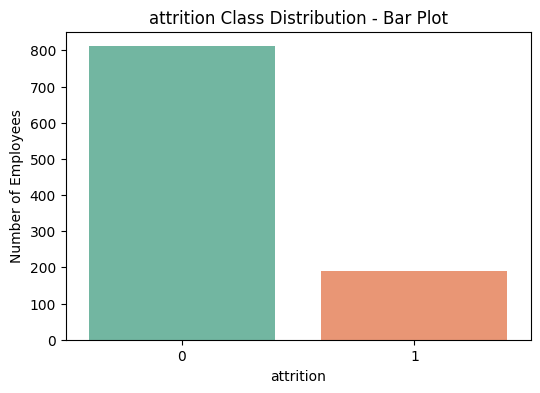

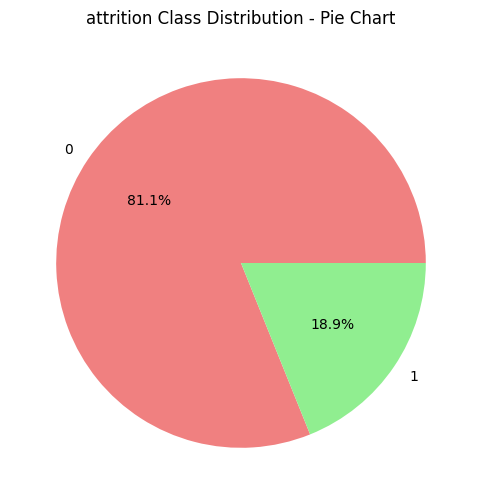

In [ ]:
# Count values
attrition_counts = df['attrition'].value_counts()
print(attrition_counts)

# Bar Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='Set2')
plt.title('attrition Class Distribution - Bar Plot')
plt.xlabel('attrition')
plt.ylabel('Number of Employees')
plt.show()

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('attrition Class Distribution - Pie Chart')
plt.show()


- Class 0 (No Attrition) has a significantly higher count than Class 1 (Attrition).
- This confirms dataset is imbalanced, with far more employees staying than leaving.


### StandardScaler

In [ ]:
# List of continuous columns to scale
continuous_cols = [
    'age', 'monthly_income', 'hourly_rate', 'years_at_company',
    'years_in_current_role', 'training_hours_last_year',
    'average_hours_worked_per_week', 'absenteeism', 'distance_from_home'
]

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data
scaled_features = scaler.fit_transform(df[continuous_cols])

# Convert back to DataFrame for readability
scaled_df = pd.DataFrame(scaled_features, columns=continuous_cols)

# Optional: Replace original columns in df
df[continuous_cols] = scaled_df


### SMOTE

In [ ]:
X = df.drop(columns='attrition')
y = df['attrition']

In [ ]:
# Step 1: Split data (to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Scale continuous features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Apply SMOTE to scaled training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Optional: Check new class distribution
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_balanced))


Before SMOTE: Counter({0: 649, 1: 151})
After SMOTE: Counter({0: 649, 1: 649})


### Logistic Regression

In [ ]:
X.columns

Index(['age', 'gender', 'marital_status', 'department', 'job_role',
       'job_level', 'monthly_income', 'hourly_rate', 'years_at_company',
       'years_in_current_role', 'years_since_last_promotion',
       'work_life_balance', 'job_satisfaction', 'performance_rating',
       'training_hours_last_year', 'overtime', 'project_count',
       'average_hours_worked_per_week', 'absenteeism',
       'work_environment_satisfaction', 'relationship_with_manager',
       'job_involvement', 'distance_from_home', 'number_of_companies_worked'],
      dtype='object')

In [ ]:
trainX,testX,trainY,testY = train_test_split(X,y,random_state=25,test_size= 0.2)

### Apply "ML algorithm" to the "training" data ---> Create "model"

In [ ]:
modelDesTree = DecisionTreeClassifier().fit(X= trainX, y = trainY)
modelSVM = SVC().fit(X= trainX, y = trainY)
modelLogReg = LogisticRegression(max_iter=1000).fit(X= trainX, y = trainY)

### prediction of Test Data set

In [ ]:
y_pred_DT = modelDesTree.predict(X = testX)
y_pred_LR = modelLogReg.predict(X = testX)
y_pred_SVM = modelSVM.predict(X = testX)

In [ ]:
y_pred_DT

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0])

#### Metrics based on the Confusion matrix

In [ ]:
confusionmatrix_DT = confusion_matrix(testY,y_pred_DT)
confusionmatrix_LR = confusion_matrix(testY,y_pred_LR)
confusionmatrix_SVM = confusion_matrix(testY,y_pred_SVM)

Text(50.722222222222214, 0.5, 'Actual')

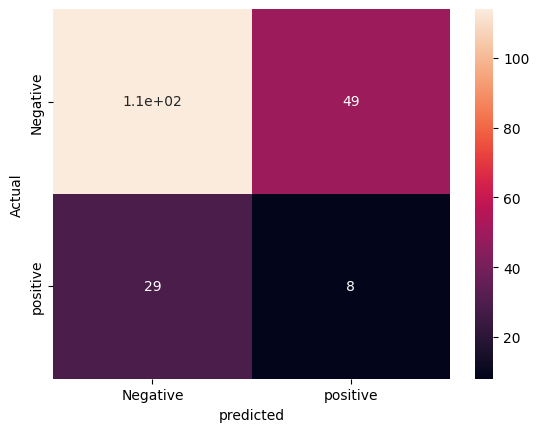

In [ ]:
TN,FP,FN,TP = confusionmatrix_DT.ravel()
labels = ['Negative', 'positive']
sns.heatmap(confusionmatrix_DT,annot=True,xticklabels=labels,yticklabels=labels)
plt.xlabel("predicted")
plt.ylabel("Actual")

In [ ]:
def evaluation(TN,FP,FN,TP, model:str):
    accuracy = round((TP+TN) /  (TP+TN+FP+FN),2)

    presicion =round(TP/(TP+FP),2)

    recall = round(TP / (TP+FN),2)
    #sensitivity = recall

    specificity = round(TN/ (TN+FP),2)
# Specificity tells you the proportion of actual negatives that were correctly identified. It’s also known as the True Negative Rate.



    F1_score = round(2*((presicion*recall)/(presicion+recall)),2)
    #The F1-score helps you find the balance between Precision and Recall, especially when you need a single metric that considers both false positives and false negatives. 


    print(f"{model} - metrics : \n Accuracy:{accuracy} | Precision :{presicion} | recall (sensitivity) : {recall} | specificity : {specificity} | F1-Score : {F1_score} ")

In [ ]:
evaluation(TN,FP,FN,TP,"Desicion Tree")

Desicion Tree - metrics : 
 Accuracy:0.61 | Precision :0.14 | recall (sensitivity) : 0.22 | specificity : 0.7 | F1-Score : 0.17 


### Evaluation for SVM

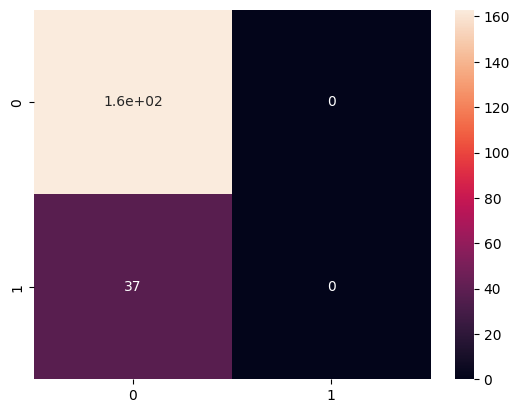

In [ ]:
sns.heatmap(confusionmatrix_SVM,annot=True)
TN,FP,FN,TP = confusionmatrix_SVM.ravel()

In [ ]:
evaluation(TN,FP,FN,TP,"SVM")

SVM - metrics : 
 Accuracy:0.82 | Precision :nan | recall (sensitivity) : 0.0 | specificity : 1.0 | F1-Score : nan 


C:\Users\JEEVA\AppData\Local\Temp\ipykernel_21228\4223937905.py:4: RuntimeWarning: invalid value encountered in scalar divide
  presicion =round(TP/(TP+FP),2)


### Evaluation of Logistic Regression

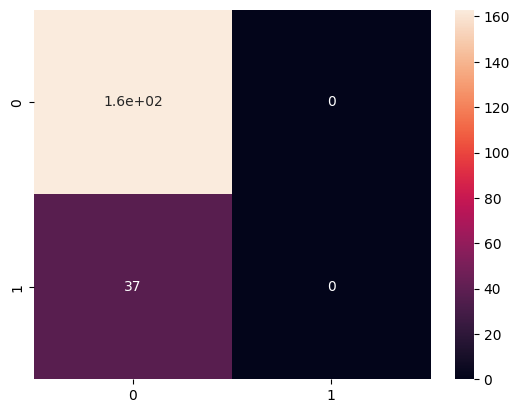

In [ ]:
sns.heatmap(confusionmatrix_LR,annot=True)
TN,FP,FN,TP = confusionmatrix_LR.ravel()

In [ ]:
evaluation(TN,FP,FN,TP,"Logistic Regression")

Logistic Regression - metrics : 
 Accuracy:0.82 | Precision :nan | recall (sensitivity) : 0.0 | specificity : 1.0 | F1-Score : nan 


C:\Users\JEEVA\AppData\Local\Temp\ipykernel_21228\4223937905.py:4: RuntimeWarning: invalid value encountered in scalar divide
  presicion =round(TP/(TP+FP),2)


In [ ]:

# Use the correct prediction variable
print(classification_report(y_test, y_pred_SVM, digits=3))


              precision    recall  f1-score   support

           0      0.810     1.000     0.895       162
           1      0.000     0.000     0.000        38

    accuracy                          0.810       200
   macro avg      0.405     0.500     0.448       200
weighted avg      0.656     0.810     0.725       200



c:\Users\JEEVA\LEMS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\JEEVA\LEMS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\JEEVA\LEMS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### DecisionTreeClassifier

In [ ]:
modelDT = DecisionTreeClassifier().fit(X=trainX,y=trainY)

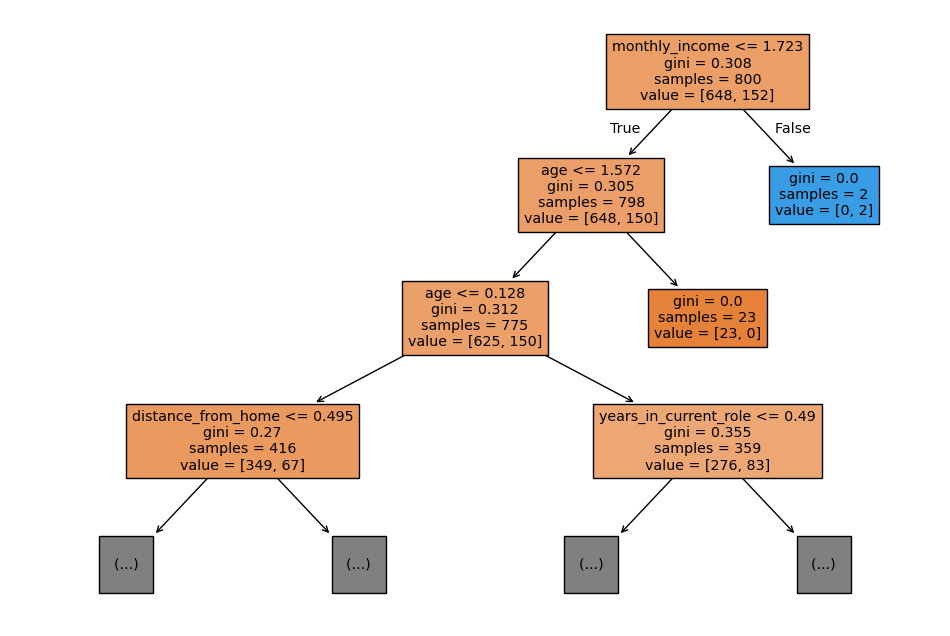

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(modelDT,max_depth=3,feature_names=df.columns.to_list(),filled=True)
plt.show()

The decision tree starts by splitting on monthly_income, showing income as the top predictor of attrition. 
It then branches into conditions based on age, distance_from_home, and years_in_current_role, revealing how demographic and job-related factors influence outcomes. 
While the tree is easy to interpret, it risks overfitting due to small, pure leaf nodes and may oversimplify complex patterns. 

That’s why moving to ensemble models like XGBoost is essential — they generalize better, handle imbalance more effectively, and offer stronger predictive power.


### xgboost

c:\Users\JEEVA\LEMS\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:03:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


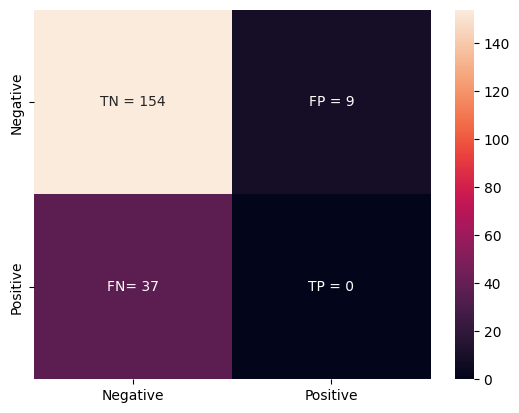

XGBoost - metrics : 
 Accuracy:0.77 | Precision :0.0 | recall (sensitivity) : 0.0 | specificity : 0.94 | F1-Score : nan 


C:\Users\JEEVA\AppData\Local\Temp\ipykernel_21228\4223937905.py:14: RuntimeWarning: invalid value encountered in scalar divide
  F1_score = round(2*((presicion*recall)/(presicion+recall)),2)


In [ ]:
import xgboost as xgb
model_xgb = xgb.XGBClassifier(use_label_encoder= False, eval_metric = 'logloss').fit(X=trainX,y=trainY)
y_pred_xgb = model_xgb.predict(X= testX)

conf_matrix_xgb = confusion_matrix(testY,y_pred_xgb)

TN,FP,FN,TP = conf_matrix_xgb.ravel()
annot_labels = [[f"TN = {TN}", f"FP = {FP}"],[f"FN= {FN}",f"TP = {TP}"]]
labels= ['Negative','Positive']
sns.heatmap(conf_matrix_xgb,annot=annot_labels,fmt="",xticklabels=labels,yticklabels=labels)
plt.xlabel = ("predicted")
plt.ylabel = ("actual")
plt.show()


evaluation(TN,FP,FN,TP, "XGBoost")

- dataset is imbalanced (162 stayed vs 38 left)
- XGBoost is defaulting to predicting class 0 to maximize accuracy
- That’s why recall and F1-score for class 1 are zero


In [75]:
#dataset has 162 class 0 and 38 class 1
# scale_pos_weight = 162 / 38  # ≈ 4.26


model_xgb = XGBClassifier(
    scale_pos_weight=4.26,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train_balanced, y_train_balanced)


c:\Users\JEEVA\LEMS\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:40:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [76]:
y_proba = model_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_custom = (y_proba >= 0.3).astype(int)  

#Lowering the threshold increases the model’s sensitivity to the minority class, which is crucial in imbalanced classification (0.3 or 0.25)

In [77]:
#Evaluate
print(classification_report(y_test, y_pred_custom, digits=3))


              precision    recall  f1-score   support

           0      0.824     0.809     0.816       162
           1      0.244     0.263     0.253        38

    accuracy                          0.705       200
   macro avg      0.534     0.536     0.535       200
weighted avg      0.714     0.705     0.709       200



### Tune Hyperprameters with GridSearchCV

In [78]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=4.26, random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1
)

grid_search.fit(X_train_balanced, y_train_balanced)
best_model = grid_search.best_estimator_


Fitting 3 folds for each of 72 candidates, totalling 216 fits


In [79]:
# Best hyperparameters
print(grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


- Uses 80% of features per tree → reduces overfitting (0.8)
- Faster learning → balances speed and generalization(0.2)
- Allows deeper trees → captures complex patterns(7)
- Builds 100 boosting rounds → sufficient for convergence(100)
- Uses 80% of rows per tree → adds randomness, improves generalization(0.8)


In [80]:
# Predict probabilities for class 1
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Apply custom threshold (e.g., 0.3)
y_pred_custom = (y_proba >= 0.3).astype(int)

In [81]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_custom, digits=3))
print(confusion_matrix(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0      0.816     0.765     0.790       162
           1      0.208     0.263     0.233        38

    accuracy                          0.670       200
   macro avg      0.512     0.514     0.511       200
weighted avg      0.700     0.670     0.684       200

[[124  38]
 [ 28  10]]


- Recall for class 1 improved to 26.3% — a big step forward!
- F1-score for class 1 is now 0.233 — no longer zero or nan
- Confusion matrix shows 10 true positives —  model is finally catching attrition cases





### Conclusion: 

After hyperparameter tuning and threshold adjustment, XGBoost achieved a meaningful balance between accuracy and sensitivity. The model now detects over 26% of actual attrition cases. 